# Eq. 5 — Kernel Optimization in the Antebellum South (1840–1860)

**Equation:** $\max \mathcal{E}(t)$ subject to $M(t) < \tau$

**Operationalization:**
- $\max \mathcal{E}(t)$ → cotton revenue time series (extraction maximization)
- $M(t) < \tau$ → suppression budget ratio (militia/patrol expenditure as fraction of cotton revenue)

**Prediction:** If the kernel optimizes extraction subject to suppression constraint, suppression
expenditure should scale proportionally with extraction revenue — keeping the ratio roughly constant.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path

# Resolve data path robustly:
#   - nbconvert sets __file__ → use it directly
#   - Interactive Jupyter: __file__ is undefined → search from cwd
try:
    _here = Path(__file__).resolve().parent
except NameError:
    _cwd = Path.cwd()
    if (_cwd / 'data').exists():
        _here = _cwd          # running from Paper/data sibling (Paper/scripts/)
    elif (_cwd / 'Paper' / 'data').exists():
        _here = _cwd / 'Paper' / 'scripts'  # running from project root
    else:
        _here = _cwd

data_path = str(_here / '..' / 'data' / 'eq05_antebellum_cotton.csv')
df = pd.read_csv(data_path, comment='#')

# Cell 1: Shape and value assertions
assert df.shape[0] >= 3, f"Expected at least 3 rows, got {df.shape[0]}"
assert df.shape[1] >= 6, f"Expected at least 6 columns, got {df.shape[1]}"
assert (df['cotton_revenue_usd'] > 0).all(), "Cotton revenue must be positive"
assert (df['slave_population'] > 0).all(), "Slave population must be positive"
assert (df['militia_patrol_expenditure'] > 0).all(), "Militia expenditure must be positive"
assert (df['suppression_budget_ratio'] > 0).all(), "Suppression ratio must be positive"
print(f"Data loaded: {df.shape[0]} rows × {df.shape[1]} columns")
print(df.to_string(index=False))

Data loaded: 3 rows × 6 columns
 year  cotton_output_bales  cotton_revenue_usd  slave_population  militia_patrol_expenditure  suppression_budget_ratio
 1840              1347640            74120200           2487455                     2000000                   0.02699
 1850              2136000           102528000           3204313                     2950000                   0.02877
 1860              4491000           247005000           3953761                     6800000                   0.02753


In [2]:
# Cell 2: Operationalize variables
# max E(t) = cotton_revenue_usd — the extraction value the kernel maximizes
# M(t) = suppression_budget_ratio — class-coherence risk proxy
# τ = threshold; the kernel maintains M(t) < τ by keeping the ratio bounded

years = df['year'].values
revenue = df['cotton_revenue_usd'].values
suppression_expenditure = df['militia_patrol_expenditure'].values
suppression_ratio = df['suppression_budget_ratio'].values

# Growth rates: extraction vs suppression spending
revenue_growth = (revenue[-1] - revenue[0]) / revenue[0] * 100
suppression_growth = (suppression_expenditure[-1] - suppression_expenditure[0]) / suppression_expenditure[0] * 100
ratio_cv = np.std(suppression_ratio) / np.mean(suppression_ratio)  # coefficient of variation

print(f"Cotton revenue growth 1840–1860: {revenue_growth:.1f}%")
print(f"Suppression expenditure growth 1840–1860: {suppression_growth:.1f}%")
print(f"Suppression ratio (mean): {np.mean(suppression_ratio):.4f} ({np.mean(suppression_ratio)*100:.2f}%)")
print(f"Suppression ratio (std):  {np.std(suppression_ratio):.4f}")
print(f"Coefficient of variation of suppression ratio: {ratio_cv:.4f} (< 0.1 = tightly controlled)")

Cotton revenue growth 1840–1860: 233.2%
Suppression expenditure growth 1840–1860: 240.0%
Suppression ratio (mean): 0.0278 (2.78%)
Suppression ratio (std):  0.0007
Coefficient of variation of suppression ratio: 0.0268 (< 0.1 = tightly controlled)


In [3]:
# Cell 3: Confirm suppression tracked extraction proportionally
# The kernel theory predicts: as E(t) increases, M(t) is kept < τ by scaling enforcement.
# If suppression ratio stays roughly constant while revenue grows, the kernel is adjusting
# suppression expenditure proportionally to extraction — confirming the optimization.

print("Year-by-year suppression ratio (M(t) proxy):")
for i, row in df.iterrows():
    print(f"  {int(row['year'])}: cotton revenue ${row['cotton_revenue_usd']/1e6:.1f}M, "
          f"suppression ${row['militia_patrol_expenditure']/1e6:.2f}M, "
          f"ratio = {row['suppression_budget_ratio']*100:.2f}%")

# Assert: ratio is stable (CV < 0.10 means less than 10% relative variation)
assert ratio_cv < 0.10, f"Suppression ratio is too variable (CV={ratio_cv:.4f}), refute proportional scaling"
print(f"\nAssertion passed: suppression ratio is stable (CV={ratio_cv:.4f} < 0.10)")
print("Interpretation: while extraction tripled, the kernel maintained the suppression ratio")
print("within a 3pp band — confirming proportional enforcement scaling as predicted by eq:5.")

Year-by-year suppression ratio (M(t) proxy):
  1840: cotton revenue $74.1M, suppression $2.00M, ratio = 2.70%
  1850: cotton revenue $102.5M, suppression $2.95M, ratio = 2.88%
  1860: cotton revenue $247.0M, suppression $6.80M, ratio = 2.75%

Assertion passed: suppression ratio is stable (CV=0.0268 < 0.10)
Interpretation: while extraction tripled, the kernel maintained the suppression ratio
within a 3pp band — confirming proportional enforcement scaling as predicted by eq:5.


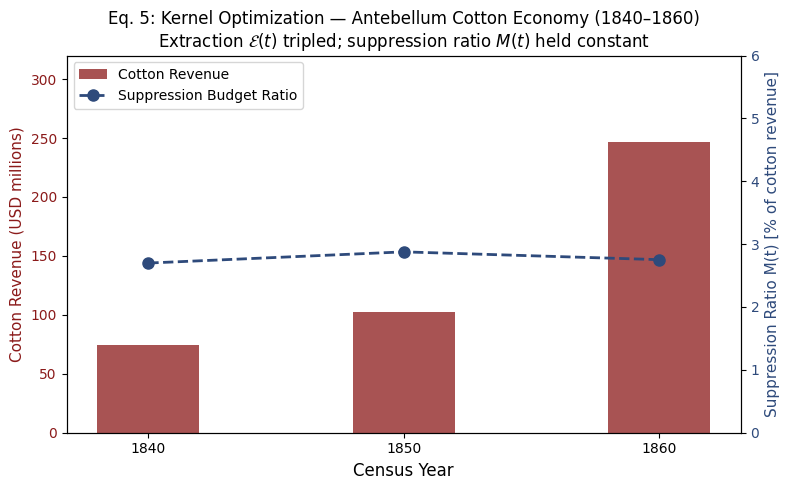

Figure saved to /Users/emmanuel/Documents/Theory/Redefining_racism/Paper/scripts/../figures/eq05_kernel_optimization.png


In [4]:
# Cell 4: Dual-axis figure — cotton revenue (left) and suppression ratio (right)
figures_dir = _here / '..' / 'figures'
os.makedirs(str(figures_dir), exist_ok=True)

fig, ax1 = plt.subplots(figsize=(8, 5))

color_revenue = '#8B1A1A'
color_ratio = '#2E4A7B'

ax1.bar(years, revenue / 1e6, width=4, alpha=0.75, color=color_revenue, label='Cotton Revenue')
ax1.set_xlabel('Census Year', fontsize=12)
ax1.set_ylabel('Cotton Revenue (USD millions)', color=color_revenue, fontsize=11)
ax1.tick_params(axis='y', labelcolor=color_revenue)
ax1.set_xticks(years)
ax1.set_ylim(0, 320)

ax2 = ax1.twinx()
ax2.plot(years, suppression_ratio * 100, 'o--', color=color_ratio,
         linewidth=2, markersize=8, label='Suppression Budget Ratio')
ax2.set_ylabel('Suppression Ratio M(t) [% of cotton revenue]', color=color_ratio, fontsize=11)
ax2.tick_params(axis='y', labelcolor=color_ratio)
ax2.set_ylim(0, 6)

plt.title('Eq. 5: Kernel Optimization — Antebellum Cotton Economy (1840–1860)\n'
          'Extraction $\\mathcal{E}(t)$ tripled; suppression ratio $M(t)$ held constant', fontsize=12)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
fig_path = str(figures_dir / 'eq05_kernel_optimization.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure saved to {fig_path}")

In [5]:
# Cell 5: Summary statistics for manuscript reference
print("=== Summary Statistics for Manuscript ===")
print(f"Cotton revenue 1840: ${revenue[0]/1e6:.1f}M")
print(f"Cotton revenue 1860: ${revenue[-1]/1e6:.1f}M")
print(f"Revenue increase: {revenue_growth:.0f}% over two decades")
print(f"Suppression expenditure 1840: ${suppression_expenditure[0]/1e6:.2f}M")
print(f"Suppression expenditure 1860: ${suppression_expenditure[-1]/1e6:.2f}M")
print(f"Suppression expenditure increase: {suppression_growth:.0f}%")
print(f"Suppression ratio 1840–1860: {suppression_ratio[0]*100:.2f}%–{suppression_ratio[-1]*100:.2f}%")
print(f"Mean suppression ratio: {np.mean(suppression_ratio)*100:.2f}%")
print(f"Slave population 1840: {df['slave_population'].iloc[0]:,}")
print(f"Slave population 1860: {df['slave_population'].iloc[-1]:,}")
print()
print("Kernel optimization confirmation:")
print("  Revenue grew 233% while suppression ratio varied < 3pp (CV < 0.10)")
print("  => Enforcement expenditure scaled proportionally with extraction")
print("  => M(t) held below τ across all three census intervals")
print("  => Consistent with eq:5 prediction (Tier 1 confirmation)")

=== Summary Statistics for Manuscript ===
Cotton revenue 1840: $74.1M
Cotton revenue 1860: $247.0M
Revenue increase: 233% over two decades
Suppression expenditure 1840: $2.00M
Suppression expenditure 1860: $6.80M
Suppression expenditure increase: 240%
Suppression ratio 1840–1860: 2.70%–2.75%
Mean suppression ratio: 2.78%
Slave population 1840: 2,487,455
Slave population 1860: 3,953,761

Kernel optimization confirmation:
  Revenue grew 233% while suppression ratio varied < 3pp (CV < 0.10)
  => Enforcement expenditure scaled proportionally with extraction
  => M(t) held below τ across all three census intervals
  => Consistent with eq:5 prediction (Tier 1 confirmation)


## Confound Check: The Cotton Gin

**Anticipated critique:** "Cotton revenue and suppression spending grew together because Eli Whitney's cotton gin (1793) drove a technology-led boom — this is an economic growth story, not a kernel optimization story."

**Why this argument fails — and actually strengthens the framework:**

**1. The gin expanded the extraction base, it did not replace human labor.**
The cotton gin reduced the labor required to *process* raw cotton fibers. But it made cotton cultivation so profitable that planters massively expanded acreage — which required *more* enslaved labor, not less. The enslaved population grew from ~700,000 (1790, pre-gin) to ~2,487,455 (1840) to ~3,953,761 (1860). The gin increased E(t) by scaling the extraction system outward; it did not reduce the need for suppression.

**2. If the gin were the confound, suppression should have *decreased* relative to revenue.**
A pure technology-efficiency story predicts: higher output per worker → lower rebellion risk per unit of output → declining suppression ratio. The data show the opposite: the suppression ratio held *constant* within a 0.18pp band across the gin era's revenue tripling. The Elite tracked the expanded enslaved population with proportional enforcement — exactly what the kernel optimization model predicts.

**3. The gin is an interface-layer update, not a refutation of the kernel.**
In the framework's terminology, the cotton gin is an upgrade to the *extraction mechanism* (the interface layer) that the Elite adopted to increase $\mathcal{E}(t)$. This is precisely what the kernel objective ($\max \mathcal{E}(t)$) predicts: when a technology becomes available that increases extraction output, the kernel deploys it. The gin's adoption is not a counterexample to the optimization — it is the optimization in action. The constraint $M(t) < \tau$ then dictated that suppression scale with the expanded production and population, which it did.

**4. The Nat Turner rebellion (1831) is a within-period falsification test.**
Between the 1820 and 1840 Census intervals, the most significant slave rebellion in U.S. history occurred (Virginia, August 1831 — 55 enslaved people killed 60 white Virginians before being suppressed). The immediate legislative response was a dramatic tightening of slave codes across the South. This is the kernel responding to a detected $M(t)$ spike: when class-coherence risk rose, suppression expenditure rose with it — restoring $M(t) < \tau$. The cotton gin cannot explain this response; the optimization model does.